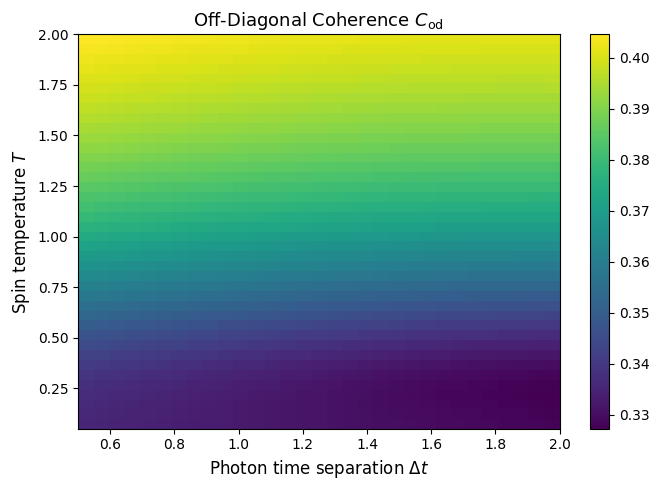

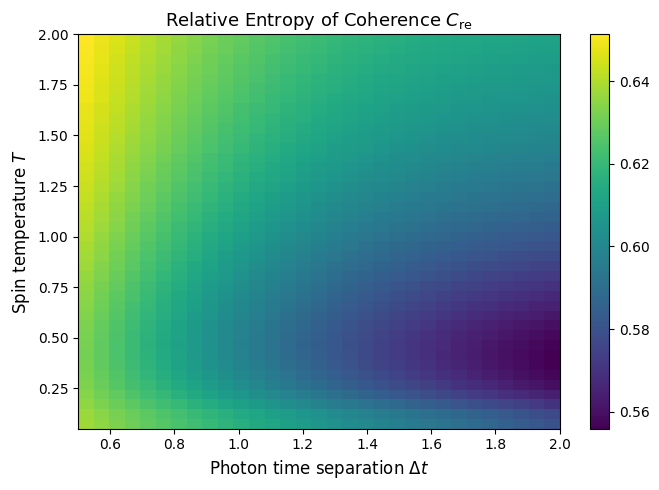

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================================
# PARAMETERS - must match simulation
# ============================================================================
n_max = 2
N_spins = 6
omega1 = 1.0
omega2 = 1.5
g1 = 2.0
g2 = 2.0
J = -1.0
delta = 0.5
tau_1 = 0.05
tau_2 = 0.05
final_evolution_time = 2.0

temperature_list = np.arange(0.05, 2.05, 0.05)
delta_t_list = np.arange(0.5, 2.05, 0.05)

save_dir = r"C:\Users\melor\OneDrive\Desktop\LM-interaction\LM-interaction\plots"

# ============================================================================
# LOAD COHERENCE DATA
# ============================================================================
offdiag_grid = np.zeros((len(temperature_list), len(delta_t_list)))
relentropy_grid = np.zeros_like(offdiag_grid)

for i, Temp_spin in enumerate(temperature_list):
    for j, delta_t in enumerate(delta_t_list):
        filename_measures = (
            f"data_coherence/coherence_measures_Nspins={N_spins}_nmax={n_max}_"
            f"omega1={omega1:1.2f}_omega2={omega2:1.2f}_J{J:1.2f}_delta={delta:1.2f}_"
            f"T={Temp_spin:1.2f}_tau1={tau_1:1.2f}_tau2={tau_2:1.2f}_"
            f"delta_t={delta_t:1.2f}_final_t={final_evolution_time:1.2f}.npy"
        )
        data = np.load(filename_measures, allow_pickle=True).item()
        offdiag_grid[i, j] = data["offdiag"]
        relentropy_grid[i, j] = data["relentropy"]

# ============================================================================
# PLOT OFF-DIAGONAL COHERENCE
# ============================================================================
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(offdiag_grid, aspect='auto', origin='lower',
    extent=[delta_t_list[0], delta_t_list[-1], temperature_list[0], temperature_list[-1]],
    cmap='viridis')
ax.set_xlabel(r'Photon time separation $\Delta t$', fontsize=12)
ax.set_ylabel(r'Spin temperature $T$', fontsize=12)
ax.set_title(r'Off-Diagonal Coherence $C_{\mathrm{od}}$', fontsize=13)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "fig_offdiagonal_coherence.png"), dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT RELATIVE ENTROPY OF COHERENCE
# ============================================================================
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(relentropy_grid, aspect='auto', origin='lower',
    extent=[delta_t_list[0], delta_t_list[-1], temperature_list[0], temperature_list[-1]],
    cmap='viridis')
ax.set_xlabel(r'Photon time separation $\Delta t$', fontsize=12)
ax.set_ylabel(r'Spin temperature $T$', fontsize=12)
ax.set_title(r'Relative Entropy of Coherence $C_{\mathrm{re}}$', fontsize=13)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "fig_relative_entropy_coherence.png"), dpi=150, bbox_inches='tight')
plt.show()